# Optimization Experiments — 2×2×2 Rubik's Cube

This notebook is **fully self-contained**: it requires only `numpy`, `torch`, and
`matplotlib` — no external project files.

**Experiments:**
1. Optimizer comparison (AdamW vs Adam vs SGD with momentum)
2. Learning rate schedule ablation (cosine annealing vs step decay vs constant)
3. Hyperparameter sensitivity (d_model sweep, weight decay sweep)
4. Learned heuristic quality (admissibility, MAE by distance, per-distance accuracy)
5. Training dynamics — multi-seed comparison
6. Loss landscape (filter-normalized, Li et al. 2018)
7. A* search with learned heuristic vs Dijkstra

---

### Kernel setup (important for runtime)

The BFS distance table and training loop are pure Python and are sensitive to
interpreter version. **Python 3.11+ is strongly recommended** — it runs the BFS
in ~10 min (chunked vectorised numpy) vs ~40+ min on Python 3.8.

If you are using `uv` (recommended), register the project's Python 3.13 kernel once:

```bash
uv run pip install ipykernel
uv run python -m ipykernel install --user --name cube-opt --display-name "Python 3.13 (cube-opt)"
```

Then select **Python 3.13 (cube-opt)** from the kernel menu before running.

---

**Expected runtimes (cold start, no cache, Python 3.13 + Apple Silicon MPS):**
- BFS distance table: ~10 min (chunked vectorised numpy)
- Dataset generation: ~5 min
- Training (22 configurations × ~2 min each on MPS, ~9 min on CPU): ~37 min (MPS) / ~3.5 hrs (CPU)
- Loss landscape: ~10 min
- **Total: ~1 hour (MPS) / ~4 hours (CPU)**

On Apple Silicon the notebook automatically uses the Metal GPU via `torch.backends.mps`
— no configuration needed. On CPU-only machines the training time dominates.

The `results/` directory included with this notebook contains the cached dataset
splits (`train.npz`, `val.npz`) and all trained-model JSON histories, reducing a
repeat run to under 15 minutes (only the best-model retrain and loss landscape
re-run unconditionally). The BFS distance table (`distances.npz`, 757 MB) is not
included and must be recomputed on a true cold start.

In [1]:
import json, time, heapq
from pathlib import Path
from collections import defaultdict, deque
from typing import Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
%matplotlib inline
import matplotlib.pyplot as plt


In [2]:
# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

NUM_STICKERS = 24
NUM_COLORS   = 6
STATE_DIM    = NUM_STICKERS * NUM_COLORS  # 144

COLOR_TO_IDX = {"W": 0, "Y": 1, "O": 2, "R": 3, "G": 4, "B": 5}
IDX_TO_COLOR = {v: k for k, v in COLOR_TO_IDX.items()}

MOVE_NAMES = ["U", "U'", "U2", "D", "D'", "D2",
              "F", "F'", "F2", "B", "B'", "B2",
              "L", "L'", "L2", "R", "R'", "R2"]
NUM_MOVES      = len(MOVE_NAMES)  # 18
MOVE_NAME_TO_IDX = {name: idx for idx, name in enumerate(MOVE_NAMES)}

# Solved state: sticker i has color SOLVED_STATE[i]
# U=W(0), D=Y(1), F=O(2), B=R(3), L=G(4), R=B(5)
SOLVED_STATE = np.array(
    [0]*4 +   # U face: stickers 0-3  -> White
    [1]*4 +   # D face: stickers 4-7  -> Yellow
    [4]*4 +   # F face: stickers 8-11 -> Green
    [5]*4 +   # B face: stickers 12-15 -> Blue
    [2]*4 +   # L face: stickers 16-19 -> Orange
    [3]*4,    # R face: stickers 20-23 -> Red
    dtype=np.int8
)

# ---------------------------------------------------------------------------
# Move permutations
# ---------------------------------------------------------------------------

FACE_ORDER = ["U", "D", "F", "B", "L", "R"]
FACE_AXES = {
    "U": {"normal": (0, 1, 0), "right": (1, 0, 0), "down": (0, 0, 1)},
    "D": {"normal": (0, -1, 0), "right": (1, 0, 0), "down": (0, 0, -1)},
    "F": {"normal": (0, 0, 1), "right": (1, 0, 0), "down": (0, -1, 0)},
    "B": {"normal": (0, 0, -1), "right": (-1, 0, 0), "down": (0, -1, 0)},
    "L": {"normal": (-1, 0, 0), "right": (0, 0, 1), "down": (0, -1, 0)},
    "R": {"normal": (1, 0, 0), "right": (0, 0, -1), "down": (0, -1, 0)},
}


def _v_add(a, b):
    return (a[0] + b[0], a[1] + b[1], a[2] + b[2])


def _v_scale(v, k):
    return (v[0] * k, v[1] * k, v[2] * k)


def _v_neg(v):
    return (-v[0], -v[1], -v[2])


def _rotate_positive_axis(vec, axis, quarter_turns):
    quarter_turns %= 4
    if quarter_turns == 0:
        return vec

    x, y, z = vec
    if axis == 0:
        rotations = {
            1: (x, -z, y),
            2: (x, -y, -z),
            3: (x, z, -y),
        }
    elif axis == 1:
        rotations = {
            1: (z, y, -x),
            2: (-x, y, -z),
            3: (-z, y, x),
        }
    else:
        rotations = {
            1: (-y, x, z),
            2: (-x, -y, z),
            3: (y, -x, z),
        }
    return rotations[quarter_turns]


def _rotate_about_normal(vec, normal, quarter_turns):
    axis = next(i for i, value in enumerate(normal) if value != 0)
    sign = normal[axis]
    return _rotate_positive_axis(vec, axis, quarter_turns * sign)


def _cw_turn_for_face(face_name):
    spec = FACE_AXES[face_name]
    up = _v_neg(spec["down"])
    if _rotate_about_normal(up, spec["normal"], 1) == spec["right"]:
        return 1
    return -1


def _build_sticker_descriptors():
    descriptors = []
    for face_name in FACE_ORDER:
        spec = FACE_AXES[face_name]
        normal = spec["normal"]
        right = spec["right"]
        down = spec["down"]
        for row in range(2):
            for col in range(2):
                row_sign = -1 if row == 0 else 1
                col_sign = -1 if col == 0 else 1
                position = _v_add(
                    normal,
                    _v_add(_v_scale(right, col_sign), _v_scale(down, row_sign)),
                )
                descriptors.append((position, normal))
    return descriptors


def _build_cw_permutation(face_name):
    spec = FACE_AXES[face_name]
    normal = spec["normal"]
    axis = next(i for i, value in enumerate(normal) if value != 0)
    layer_value = normal[axis]
    quarter_turn = _cw_turn_for_face(face_name)

    permutation = np.arange(NUM_STICKERS, dtype=np.int8)
    for old_idx, (position, sticker_normal) in enumerate(STICKER_DESCRIPTORS):
        if position[axis] != layer_value:
            continue
        new_position = _rotate_about_normal(position, normal, quarter_turn)
        new_normal = _rotate_about_normal(sticker_normal, normal, quarter_turn)
        new_idx = STICKER_INDEX[(new_position, new_normal)]
        permutation[new_idx] = old_idx
    return permutation


def _build_global_rotation_permutation(axis, quarter_turns):
    permutation = np.arange(NUM_STICKERS, dtype=np.int8)
    for old_idx, (position, sticker_normal) in enumerate(STICKER_DESCRIPTORS):
        new_position = _rotate_positive_axis(position, axis, quarter_turns)
        new_normal = _rotate_positive_axis(sticker_normal, axis, quarter_turns)
        new_idx = STICKER_INDEX[(new_position, new_normal)]
        permutation[new_idx] = old_idx
    return permutation


def _build_cube_rotation_permutations():
    identity = np.arange(NUM_STICKERS, dtype=np.int8)
    generators = [
        _build_global_rotation_permutation(axis=0, quarter_turns=1),
        _build_global_rotation_permutation(axis=1, quarter_turns=1),
        _build_global_rotation_permutation(axis=2, quarter_turns=1),
    ]

    permutations = [identity]
    seen = {tuple(int(idx) for idx in identity)}
    queue = [identity]

    while queue:
        current = queue.pop()
        for generator in generators:
            composed = current[generator]
            key = tuple(int(idx) for idx in composed)
            if key in seen:
                continue
            seen.add(key)
            permutations.append(composed)
            queue.append(composed)

    return permutations


STICKER_DESCRIPTORS = _build_sticker_descriptors()
STICKER_INDEX = {descriptor: idx for idx, descriptor in enumerate(STICKER_DESCRIPTORS)}
BASE_PERMUTATIONS = [_build_cw_permutation(face_name) for face_name in FACE_ORDER]
INV_PERMUTATIONS = [np.argsort(p).astype(np.int8) for p in BASE_PERMUTATIONS]
CUBE_ROTATION_PERMUTATIONS = _build_cube_rotation_permutations()
SOLVED_SYMMETRY_STATES = np.stack(
    [SOLVED_STATE[permutation] for permutation in CUBE_ROTATION_PERMUTATIONS]
)

# Base-6 packing: a (24,) state in [0..5] fits in uint64
_POWERS_OF_6 = (6 ** np.arange(NUM_STICKERS, dtype=np.uint64)).astype(np.uint64)


def pack_state(state):
    "Pack a (24,) int8 state with values in [0..5] to a unique uint64."
    return int((np.asarray(state, dtype=np.uint64) * _POWERS_OF_6).sum())


def _pack_states_batch(states):
    "Vectorized pack_state over a (N, 24) array."
    return (states.astype(np.uint64) * _POWERS_OF_6).sum(axis=1)


class DistanceTable:
    "Dict-like wrapper over sorted uint64 keys + int8 distances."

    def __init__(self, keys, values):
        self._keys = np.asarray(keys, dtype=np.uint64)
        self._values = np.asarray(values, dtype=np.int8)

    def _as_packed(self, key):
        if isinstance(key, (bytes, bytearray, memoryview)):
            return pack_state(np.frombuffer(bytes(key), dtype=np.int8))
        if isinstance(key, np.ndarray):
            return pack_state(key)
        return int(key)

    def __getitem__(self, key):
        k = self._as_packed(key)
        idx = int(np.searchsorted(self._keys, np.uint64(k)))
        if idx < len(self._keys) and int(self._keys[idx]) == k:
            return int(self._values[idx])
        raise KeyError(key)

    def get(self, key, default=None):
        try:
            return self[key]
        except KeyError:
            return default

    def __contains__(self, key):
        return self.get(key, None) is not None

    def __len__(self):
        return int(len(self._keys))

    def values(self):
        return (int(v) for v in self._values)

    @classmethod
    def load(cls, path):
        "Memory-map an .npz file saved by save()."
        data = np.load(path, mmap_mode="r")
        return cls(data["keys"], data["values"])

    def save(self, path):
        "Write to .npz."
        np.savez(path, keys=self._keys, values=self._values)


CORNER_STICKERS = [
    (3, 9, 20),   # UFR
    (2, 8, 17),   # UFL
    (0, 13, 16),  # UBL
    (1, 12, 21),  # UBR
    (5, 11, 22),  # DFR
    (4, 10, 19),  # DFL
    (6, 15, 18),  # DBL
    (7, 14, 23),  # DBR
]
VALID_CORNER_COLOR_SETS = {
    tuple(sorted(int(SOLVED_STATE[idx]) for idx in stickers))
    for stickers in CORNER_STICKERS
}

# ---------------------------------------------------------------------------
# Cube class
# ---------------------------------------------------------------------------

class Cube:
    "2x2x2 Rubik's Cube."

    def __init__(self, state=None):
        if state is not None:
            if state.shape != (NUM_STICKERS,):
                raise ValueError(f"State must have shape ({NUM_STICKERS},), got {state.shape}")
            self.state = state.astype(np.int8)
        else:
            self.state = SOLVED_STATE.copy()

    def apply_move(self, move_idx):
        if not 0 <= move_idx < NUM_MOVES:
            raise ValueError(f"Invalid move index {move_idx}")
        face_idx = move_idx // 3
        turn_type = move_idx % 3

        if turn_type == 0:
            self.state = self.state[BASE_PERMUTATIONS[face_idx]]
        elif turn_type == 1:
            self.state = self.state[INV_PERMUTATIONS[face_idx]]
        else:
            p = BASE_PERMUTATIONS[face_idx]
            self.state = self.state[p][p]

        return self

    def apply_move_name(self, name):
        if name not in MOVE_NAME_TO_IDX:
            raise ValueError(f"Unknown move name {name!r}")
        return self.apply_move(MOVE_NAME_TO_IDX[name])

    def scramble(self, n, rng=None):
        if rng is None:
            rng = np.random.default_rng()

        moves = []
        last_face = -1
        for _ in range(n):
            candidates = [m for m in range(NUM_MOVES) if m // 3 != last_face]
            move = int(rng.choice(candidates))
            self.apply_move(move)
            moves.append(move)
            last_face = move // 3
        return moves

    @classmethod
    def from_scramble(cls, n, rng=None):
        cube = cls()
        moves = cube.scramble(n, rng)
        return cube, moves

    def encode(self):
        return np.eye(NUM_COLORS, dtype=np.float32)[self.state].flatten()

    @staticmethod
    def decode(encoded):
        if encoded.shape != (STATE_DIM,):
            raise ValueError(f"Encoded state must have shape ({STATE_DIM},), got {encoded.shape}")
        oh = encoded.reshape(NUM_STICKERS, NUM_COLORS)
        state = oh.argmax(axis=1).astype(np.int8)
        return Cube(state)

    def is_solved(self):
        return bool(np.any(np.all(SOLVED_SYMMETRY_STATES == self.state, axis=1)))

    def face_solved(self):
        solved = np.zeros(6, dtype=bool)
        for f in range(6):
            face_stickers = self.state[f*4 : f*4+4]
            solved[f] = bool((face_stickers == face_stickers[0]).all())
        return solved

    def corner_oriented(self):
        ud_colors = {COLOR_TO_IDX["W"], COLOR_TO_IDX["Y"]}
        oriented = np.zeros(8, dtype=bool)
        for i, (ud_idx, _, _) in enumerate(CORNER_STICKERS):
            oriented[i] = self.state[ud_idx] in ud_colors
        return oriented

    def copy(self):
        return Cube(self.state.copy())

    def __repr__(self):
        colors = [IDX_TO_COLOR[int(c)] for c in self.state]
        faces = ["U", "D", "F", "B", "L", "R"]
        lines = []
        for f, name in enumerate(faces):
            row = colors[f*4 : f*4+4]
            lines.append(f"{name}: [{row[0]}{row[1]}|{row[2]}{row[3]}]")
        return "  ".join(lines)


# ---------------------------------------------------------------------------
# Optimal distance (BFS)
# ---------------------------------------------------------------------------

def compute_optimal_distances(verbose=True):
    """BFS over all 88M reachable states.

    Two speedups over naive BFS:
    - Vectorized frontier expansion: all 18 moves applied to the entire
      frontier simultaneously via numpy fancy indexing, replacing N*18
      individual Python array operations with ~4 numpy calls per level.
    - Integer keys: packed uint64 keys hash in O(1) vs O(24) for bytes keys.
    """
    # Pre-build (18, 24) index array — one row per move
    _all_perms = np.empty((NUM_MOVES, NUM_STICKERS), dtype=np.intp)
    for m in range(NUM_MOVES):
        face_idx = m // 3
        turn_type = m % 3
        if turn_type == 0:
            _all_perms[m] = BASE_PERMUTATIONS[face_idx]
        elif turn_type == 1:
            _all_perms[m] = INV_PERMUTATIONS[face_idx]
        else:
            p = BASE_PERMUTATIONS[face_idx]
            _all_perms[m] = p[p]

    # int(packed uint64) -> distance; integer keys hash in O(1)
    visited: dict = {int(pack_state(SOLVED_STATE)): 0}
    frontier = np.array([SOLVED_STATE], dtype=np.int8)  # (N, 24)
    d = 0
    t0 = time.perf_counter()

    CHUNK = 50_000  # bound memory: 50k states × 18 moves × 24 bytes = ~21 MB/chunk

    while len(frontier) > 0:
        d += 1
        new_parts = []

        for start in range(0, len(frontier), CHUNK):
            chunk = frontier[start:start + CHUNK]
            # Apply all 18 moves to this chunk: (C, 24) -> (C, 18, 24) -> (C*18, 24)
            succ = chunk[:, _all_perms].reshape(-1, 24)
            keys = _pack_states_batch(succ)  # (C*18,) uint64, vectorized

            mask = np.zeros(len(keys), dtype=bool)
            for i, k in enumerate(keys.tolist()):
                if k not in visited:
                    mask[i] = True
                    visited[k] = d
            new_parts.append(succ[mask])

        frontier = np.concatenate(new_parts) if new_parts else np.empty((0, 24), dtype=np.int8)

        if verbose:
            elapsed = time.perf_counter() - t0
            print(f"  distance {d:2d}: {len(frontier):>12,} states  ({elapsed:.1f}s)")

    if verbose:
        elapsed = time.perf_counter() - t0
        print(f"  total: {len(visited):,} states  ({elapsed:.1f}s)")
        print("  packing and sorting for on-disk format...", end=" ", flush=True)

    t_pack = time.perf_counter()
    packed = np.fromiter(visited.keys(), dtype=np.uint64, count=len(visited))
    values = np.fromiter(visited.values(), dtype=np.int8, count=len(visited))
    order = np.argsort(packed)
    table = DistanceTable(packed[order], values[order])

    if verbose:
        print(f"{time.perf_counter() - t_pack:.1f}s")
    return table


# ---------------------------------------------------------------------------
# Dataset generation
# ---------------------------------------------------------------------------

def generate_dataset(n_sequences, max_scramble_depth=11, rng=None, distances=None):
    "Generate a dataset of (state, next_move) pairs from random scramble sequences."
    if rng is None:
        rng = np.random.default_rng(42)

    all_states, all_moves, all_depths = [], [], []
    all_face_solved, all_corner_oriented = [], []
    all_optimal = [] if distances is not None else None

    for _ in range(n_sequences):
        depth = int(rng.integers(1, max_scramble_depth + 1))
        cube = Cube()
        moves = cube.scramble(depth, rng)

        replay = Cube()
        for step, move in enumerate(moves):
            all_states.append(replay.encode())
            all_moves.append(move)
            all_depths.append(step)
            all_face_solved.append(replay.face_solved())
            all_corner_oriented.append(replay.corner_oriented())
            if distances is not None:
                all_optimal.append(distances[replay.state.tobytes()])
            replay.apply_move(move)

    result = {
        "states":          np.stack(all_states).astype(np.float32),
        "next_moves":      np.array(all_moves, dtype=np.int64),
        "scramble_depth":  np.array(all_depths, dtype=np.int32),
        "face_solved":     np.stack(all_face_solved),
        "corner_oriented": np.stack(all_corner_oriented),
    }
    if distances is not None:
        result["optimal_distance"] = np.array(all_optimal, dtype=np.int8)
    return result


print("Cube simulator loaded.")
print(f"  STATE_DIM={STATE_DIM}, NUM_MOVES={NUM_MOVES}")
print(f"  24 cube rotational symmetries: {len(CUBE_ROTATION_PERMUTATIONS)}")

Cube simulator loaded.
  STATE_DIM=144, NUM_MOVES=18
  24 cube rotational symmetries: 24


In [3]:
class Attention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, D = x.shape
        q, k, v = self.qkv(x.unsqueeze(1)).chunk(3, dim=-1)
        q = q.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, 1, self.n_heads, self.d_head).transpose(1, 2)
        attn = F.softmax(q @ k.transpose(-2, -1) * self.d_head ** -0.5, dim=-1)
        return self.out_proj((attn @ v).transpose(1, 2).reshape(B, D))


class MLP(nn.Module):
    def __init__(self, d_model, mlp_mult=4):
        super().__init__()
        self.fc1 = nn.Linear(d_model, mlp_mult * d_model)
        self.fc2 = nn.Linear(mlp_mult * d_model, d_model)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_mult=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = Attention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, mlp_mult)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class CubeTransformer(nn.Module):
    def __init__(self, d_model=128, n_layers=4, n_heads=4, mlp_mult=4, n_classes=12):
        super().__init__()
        self.embed = nn.Linear(STATE_DIM, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, mlp_mult) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes, bias=False)

    def forward(self, x):
        x = self.embed(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.ln_final(x))

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


print(f"CubeTransformer defined. Default param count: {CubeTransformer().n_params:,}")


CubeTransformer defined. Default param count: 811,392


In [4]:
NOTEBOOK_DIR = Path(".")
RESULTS_DIR = NOTEBOOK_DIR / "results"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Device: {device}")


Device: mps


## Dataset Generation — BFS + Scrambling

The dataset is built in two steps:

1. **BFS distance table** (~25–30 min): A full BFS from the solved state over all
   ~88 million reachable 2×2×2 states, recording the optimal HTM distance for each.
   Saved as a compact `.npz` (sorted uint64 keys + int8 values) for fast lookup.

2. **Scramble-based dataset** (~3 min): Random scrambles of depth 1–11 are generated.
   For each step of each scramble, the current state and the next move are recorded,
   along with the optimal distance from the BFS table.

Both outputs are cached to `results/`; subsequent runs load instantly.


In [5]:
DISTANCES_CACHE = RESULTS_DIR / "distances.npz"
TRAIN_CACHE = RESULTS_DIR / "train.npz"
VAL_CACHE   = RESULTS_DIR / "val.npz"

# Step 1: BFS distance table
if DISTANCES_CACHE.exists():
    print("Loading cached distance table...")
    distances = DistanceTable.load(DISTANCES_CACHE)
    print(f"  {len(distances):,} states loaded")
else:
    print("Computing BFS distance table (25-30 min)...")
    distances = compute_optimal_distances(verbose=True)
    distances.save(DISTANCES_CACHE)
    print(f"Saved to {DISTANCES_CACHE}")


# Step 2: Generate train/val splits
def _gen_and_save(path, n_sequences, seed):
    rng = np.random.default_rng(seed)
    data = generate_dataset(n_sequences, max_scramble_depth=11, rng=rng, distances=distances)
    np.savez_compressed(path, **data)
    return data


if TRAIN_CACHE.exists() and VAL_CACHE.exists():
    print("Loading cached train/val splits...")
    train_data = {k: v for k, v in np.load(TRAIN_CACHE).items()}
    val_data   = {k: v for k, v in np.load(VAL_CACHE).items()}
else:
    print("Generating train split (50,000 sequences)...")
    train_data = _gen_and_save(TRAIN_CACHE, 50_000, seed=0)
    print("Generating val split (5,000 sequences)...")
    val_data   = _gen_and_save(VAL_CACHE,   5_000,  seed=1)

print(f"Train: {len(train_data['states']):,}  Val: {len(val_data['states']):,}")


Loading cached distance table...
  88,179,840 states loaded
Loading cached train/val splits...
Train: 298,810  Val: 29,995


In [6]:
def make_loader(data, batch_size, shuffle):
    ds = TensorDataset(
        torch.from_numpy(data["states"].astype("float32")),
        torch.from_numpy(data["optimal_distance"].astype("int64")),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


BATCH_SIZE = 512
train_loader = make_loader(train_data, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_data,   BATCH_SIZE, shuffle=False)

# Inverse-frequency class weights (same as train.py)
train_labels = torch.from_numpy(train_data["optimal_distance"].astype("int64"))
counts = torch.bincount(train_labels, minlength=12).float()
class_weights = (1.0 / (counts + 1))
class_weights = class_weights / class_weights.sum() * 12

print(f"Train: {len(train_loader.dataset):,}  Val: {len(val_loader.dataset):,}")
print(f"Class weights: min={class_weights.min():.2f}  max={class_weights.max():.2f}")


Train: 298,810  Val: 29,995
Class weights: min=0.00  max=11.74


In [7]:
@torch.no_grad()
def evaluate(model, loader, device, class_weights):
    "Returns (val_loss, val_acc, depth_acc, depth_mae, depth_pred_errors)."
    model.eval()
    cw = class_weights.to(device)
    total_loss = total_correct = total = 0
    depth_preds = defaultdict(list)

    for states, targets in loader:
        states, targets = states.to(device), targets.to(device)
        logits = model(states)
        loss   = F.cross_entropy(logits, targets, weight=cw, reduction="sum")
        preds  = logits.argmax(dim=-1)

        total_loss    += loss.item()
        total_correct += (preds == targets).sum().item()
        total         += len(targets)

        for t, p in zip(targets.cpu().numpy(), preds.cpu().numpy()):
            depth_preds[int(t)].append(int(p))

    acc  = total_correct / total
    loss = total_loss / total
    depth_acc = {d: float(np.mean(np.array(depth_preds[d]) == d))   for d in sorted(depth_preds)}
    depth_mae = {d: float(np.mean(np.abs(np.array(depth_preds[d]) - d))) for d in sorted(depth_preds)}
    depth_errors = {d: (np.array(depth_preds[d]) - d).tolist() for d in sorted(depth_preds)}

    return loss, acc, depth_acc, depth_mae, depth_errors


def run_experiment(
    name,
    optimizer_type="adamw",
    scheduler_type="cosine",
    d_model=128,
    n_layers=4,
    n_heads=4,
    lr=1e-3,
    wd=1e-4,
    epochs=30,
    force=False,
):
    "Train a model and return history. Caches to results/{name}.json."
    out_path = RESULTS_DIR / f"{name}.json"
    if out_path.exists() and not force:
        print(f"  [cached]  {name}")
        return json.loads(out_path.read_text())

    print(f"  [running] {name}  ({optimizer_type}, {scheduler_type}, d={d_model}, lr={lr:.0e}, wd={wd:.0e})")
    model = CubeTransformer(
        d_model=d_model, n_layers=n_layers, n_heads=n_heads, n_classes=12
    ).to(device)

    if optimizer_type == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif optimizer_type == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif optimizer_type == "sgd":
        opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_type}")

    if scheduler_type == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 20)
    elif scheduler_type == "constant":
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda e: 1.0)
    elif scheduler_type == "step":
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.3)
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_type}")

    cw = class_weights.to(device)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.perf_counter()
        running_loss = 0.0

        for states, targets in train_loader:
            states, targets = states.to(device), targets.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(states), targets, weight=cw)
            loss.backward()
            opt.step()
            running_loss += loss.item()

        sched.step()
        train_loss = running_loss / len(train_loader)
        val_loss, val_acc, depth_acc, depth_mae, depth_errors = evaluate(
            model, val_loader, device, class_weights
        )
        elapsed = time.perf_counter() - t0
        current_lr = sched.get_last_lr()[0]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "depth_acc": depth_acc,
            "depth_mae": depth_mae,
            "depth_errors": depth_errors,
            "lr": current_lr,
            "elapsed": elapsed,
        })

        if epoch % 10 == 0 or epoch == epochs:
            print(f"    epoch {epoch:3d}  val_acc={val_acc*100:.1f}%  loss={val_loss:.4f}  lr={current_lr:.2e}  ({elapsed:.1f}s)")

    out_path.write_text(json.dumps(history, indent=2))
    print(f"  -> saved {out_path}")
    return history


In [8]:
print("=== 1. Optimizer Comparison ===")
results_opt = {
    "adamw": run_experiment("opt_adamw", optimizer_type="adamw", scheduler_type="cosine", lr=1e-3),
    "adam":  run_experiment("opt_adam",  optimizer_type="adam",  scheduler_type="cosine", lr=1e-3),
    "sgd":   run_experiment("opt_sgd",   optimizer_type="sgd",   scheduler_type="cosine", lr=0.05),
}


=== 1. Optimizer Comparison ===
  [cached]  opt_adamw
  [cached]  opt_adam
  [cached]  opt_sgd


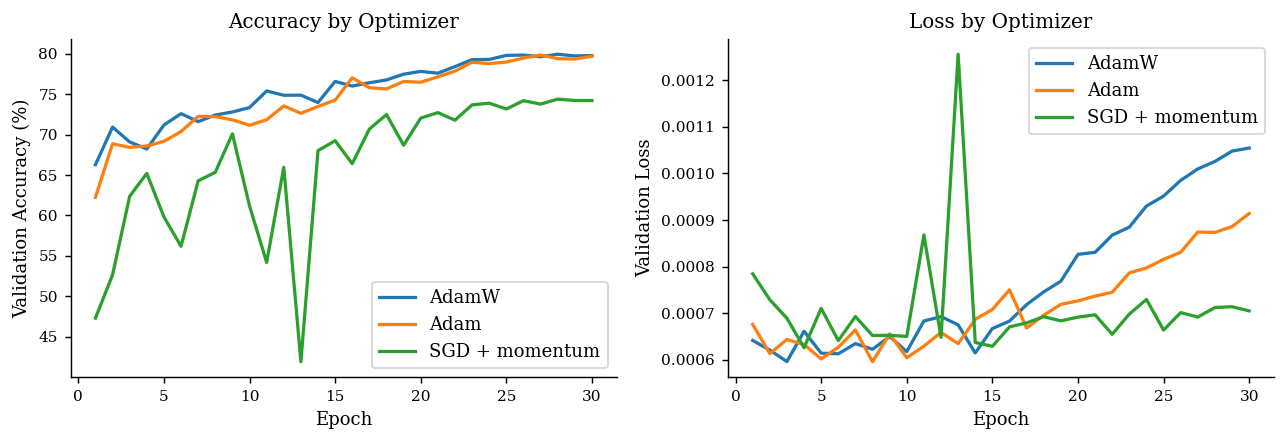

Saved optimizer_comparison.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
colors = {"adamw": "#1f77b4", "adam": "#ff7f0e", "sgd": "#2ca02c"}
labels = {"adamw": "AdamW", "adam": "Adam", "sgd": "SGD + momentum"}

for key, hist in results_opt.items():
    epochs_x = [h["epoch"]       for h in hist]
    val_acc  = [h["val_acc"]*100 for h in hist]
    val_loss = [h["val_loss"]    for h in hist]
    c = colors[key]
    axes[0].plot(epochs_x, val_acc,  color=c, label=labels[key], linewidth=1.8)
    axes[1].plot(epochs_x, val_loss, color=c, label=labels[key], linewidth=1.8)

for ax, ylabel, title in zip(axes,
    ["Validation Accuracy (%)", "Validation Loss"],
    ["Accuracy by Optimizer",   "Loss by Optimizer"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "optimizer_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved optimizer_comparison.pdf")


In [10]:
print("=== 2. LR Schedule Ablation ===")
results_sched = {
    "cosine":   run_experiment("sched_cosine",   optimizer_type="adamw", scheduler_type="cosine",   lr=1e-3),
    "step":     run_experiment("sched_step",     optimizer_type="adamw", scheduler_type="step",     lr=1e-3),
    "constant": run_experiment("sched_constant", optimizer_type="adamw", scheduler_type="constant", lr=1e-3),
}


=== 2. LR Schedule Ablation ===
  [cached]  sched_cosine
  [cached]  sched_step
  [cached]  sched_constant


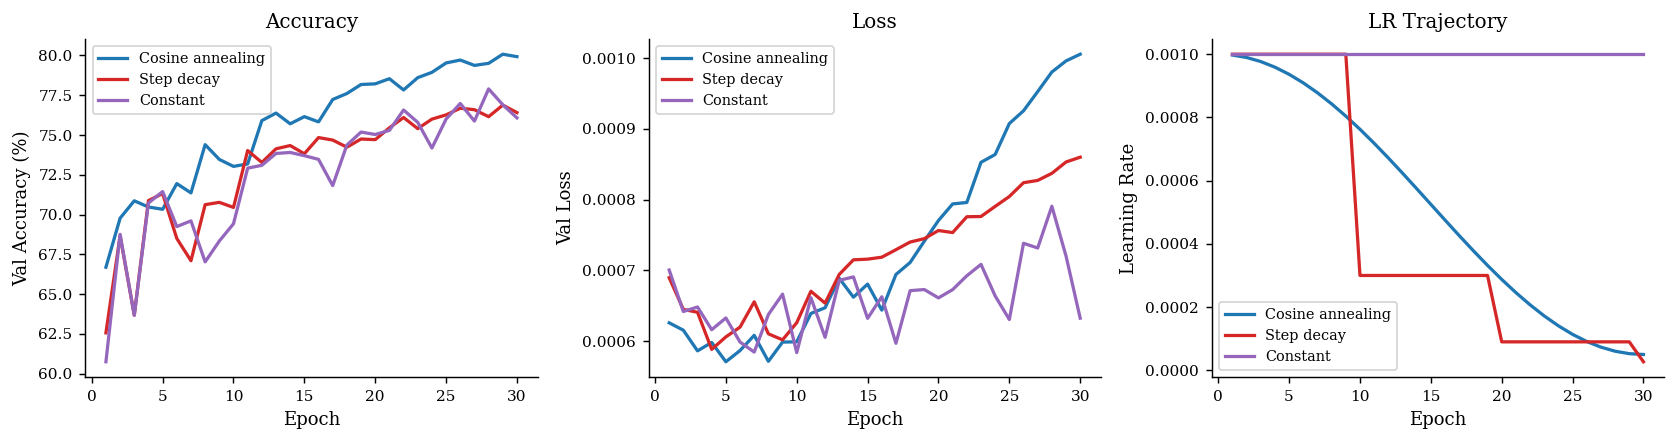

Saved schedule_comparison.pdf


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
colors_s = {"cosine": "#1f77b4", "step": "#d62728", "constant": "#9467bd"}
labels_s = {"cosine": "Cosine annealing", "step": "Step decay", "constant": "Constant"}

for key, hist in results_sched.items():
    epochs_x = [h["epoch"]       for h in hist]
    val_acc  = [h["val_acc"]*100 for h in hist]
    val_loss = [h["val_loss"]    for h in hist]
    lrs      = [h["lr"]          for h in hist]
    c = colors_s[key]
    axes[0].plot(epochs_x, val_acc,  color=c, label=labels_s[key], linewidth=1.8)
    axes[1].plot(epochs_x, val_loss, color=c, label=labels_s[key], linewidth=1.8)
    axes[2].plot(epochs_x, lrs,      color=c, label=labels_s[key], linewidth=1.8)

for ax, ylabel, title in zip(axes,
    ["Val Accuracy (%)", "Val Loss", "Learning Rate"],
    ["Accuracy",         "Loss",     "LR Trajectory"]):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "schedule_comparison.pdf", bbox_inches="tight")
plt.show()
print("Saved schedule_comparison.pdf")


## Training Dynamics — Multi-Seed Comparison

Train each of AdamW, Adam, and SGD+momentum for 3 independent seeds (0, 1, 2)
to assess variance across initializations. Results are cached as
`results/multi_seed_{opt}_s{seed}.json`.


In [12]:
SEEDS = [0, 1, 2]

optimizer_ms_configs = {
    "adamw": dict(optimizer_type="adamw", scheduler_type="cosine", lr=1e-3),
    "adam":  dict(optimizer_type="adam",  scheduler_type="cosine", lr=1e-3),
    "sgd":   dict(optimizer_type="sgd",   scheduler_type="cosine", lr=0.05),
}


def run_multiseed_one(name, seed, optimizer_type, scheduler_type, lr, wd=1e-4, epochs=30):
    "Train one model for one seed, caching to results/multi_seed_{name}_s{seed}.json."
    out = RESULTS_DIR / f"multi_seed_{name}_s{seed}.json"
    if out.exists():
        print(f"  [cached] {name} seed={seed}")
        return json.loads(out.read_text())

    print(f"  [run]    {name} seed={seed}  ({optimizer_type}, {scheduler_type}, lr={lr:.0e})")
    torch.manual_seed(seed)

    model = CubeTransformer(d_model=128, n_layers=4, n_heads=4, n_classes=12).to(device)

    if optimizer_type == "adamw":
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif optimizer_type == "adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:  # sgd
        opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

    if scheduler_type == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr / 20)
    elif scheduler_type == "step":
        sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.3)
    else:
        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda e: 1.0)

    cw = class_weights.to(device)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        for states_b, targets_b in train_loader:
            states_b, targets_b = states_b.to(device), targets_b.to(device)
            opt.zero_grad(set_to_none=True)
            F.cross_entropy(model(states_b), targets_b, weight=cw).backward()
            opt.step()
        sched.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for states_b, targets_b in val_loader:
                states_b, targets_b = states_b.to(device), targets_b.to(device)
                correct += (model(states_b).argmax(1) == targets_b).sum().item()
                total   += len(targets_b)
        val_acc = correct / total
        history.append({"epoch": epoch, "val_acc": val_acc})

        if epoch % 10 == 0 or epoch == epochs:
            print(f"    epoch {epoch:3d}  val_acc={val_acc*100:.1f}%")

    out.write_text(json.dumps(history))
    return history


print("=== Multi-seed training ===")
results_multiseed = {}
for opt_name, cfg in optimizer_ms_configs.items():
    for seed in SEEDS:
        hist = run_multiseed_one(opt_name, seed, **cfg)
        results_multiseed[(opt_name, seed)] = hist

print("Done. results_multiseed keys:", list(results_multiseed.keys()))


=== Multi-seed training ===
  [cached] adamw seed=0
  [cached] adamw seed=1
  [cached] adamw seed=2
  [cached] adam seed=0
  [cached] adam seed=1
  [cached] adam seed=2
  [cached] sgd seed=0
  [cached] sgd seed=1
  [cached] sgd seed=2
Done. results_multiseed keys: [('adamw', 0), ('adamw', 1), ('adamw', 2), ('adam', 0), ('adam', 1), ('adam', 2), ('sgd', 0), ('sgd', 1), ('sgd', 2)]


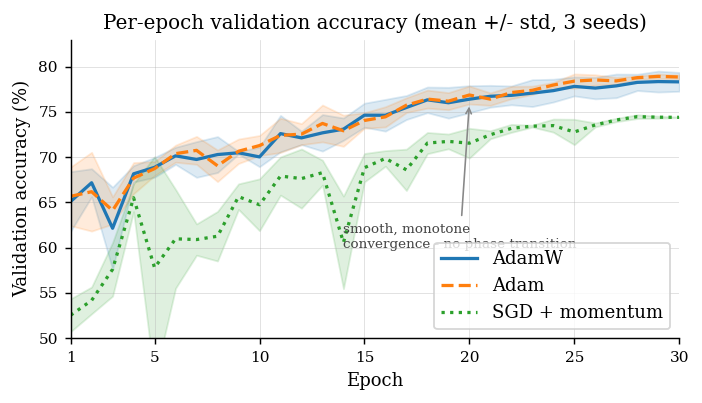

Saved training_dynamics.pdf


In [13]:
COLORS_MS    = {"adamw": "#1f77b4", "adam": "#ff7f0e", "sgd": "#2ca02c"}
LABELS_MS    = {"adamw": "AdamW", "adam": "Adam", "sgd": "SGD + momentum"}
LINESTYLE_MS = {"adamw": "-", "adam": "--", "sgd": ":"}

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.2))

epochs_arr = np.arange(1, 31)
for opt_name in ["adamw", "adam", "sgd"]:
    accs = []
    for seed in SEEDS:
        hist = results_multiseed[(opt_name, seed)]
        accs.append([h["val_acc"] * 100 for h in hist])
    accs = np.array(accs)  # shape (3, 30)
    mean = accs.mean(axis=0)
    std  = accs.std(axis=0)
    c = COLORS_MS[opt_name]
    ax.plot(epochs_arr, mean, color=c, label=LABELS_MS[opt_name],
            linestyle=LINESTYLE_MS[opt_name], linewidth=1.8)
    ax.fill_between(epochs_arr, mean - std, mean + std, color=c, alpha=0.15)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy (%)")
ax.set_xlim(1, 30)
ax.set_ylim(50, 83)
ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
ax.legend(loc="lower right")
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.set_title("Per-epoch validation accuracy (mean +/- std, 3 seeds)")

ax.annotate("smooth, monotone\nconvergence - no phase transition",
            xy=(20, 76), xytext=(14, 60),
            fontsize=7.5, color="#444444",
            arrowprops=dict(arrowstyle="->", color="#888888", lw=0.9))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_dynamics.pdf", bbox_inches="tight")
plt.show()
print("Saved training_dynamics.pdf")


In [14]:
print("=== 3. Hyperparameter Sensitivity ===")

# Width sweep
d_models = [64, 128, 256]
results_dmodel = {}
for d in d_models:
    results_dmodel[d] = run_experiment(
        f"dmodel_{d}", optimizer_type="adamw", scheduler_type="cosine",
        d_model=d, lr=1e-3, wd=1e-4,
    )

# Weight decay sweep
wd_values = [0.0, 1e-4, 1e-3, 1e-2]
results_wd = {}
for wd in wd_values:
    name = f"wd_{wd:.0e}" if wd > 0 else "wd_0"
    results_wd[wd] = run_experiment(
        name, optimizer_type="adamw", scheduler_type="cosine",
        d_model=128, lr=1e-3, wd=wd,
    )


=== 3. Hyperparameter Sensitivity ===
  [cached]  dmodel_64
  [cached]  dmodel_128
  [cached]  dmodel_256
  [cached]  wd_0
  [cached]  wd_1e-04
  [cached]  wd_1e-03
  [cached]  wd_1e-02


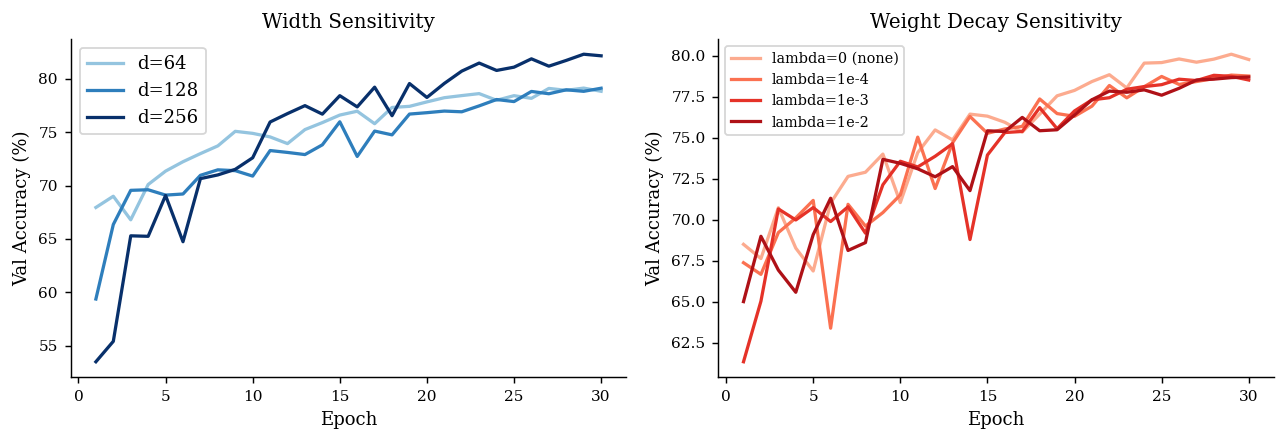

Saved hyperparameter_sensitivity.pdf


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Width sweep: convergence curves
cmap_d = plt.cm.Blues
for i, (d, hist) in enumerate(sorted(results_dmodel.items())):
    c = cmap_d(0.4 + 0.3 * i)
    epochs_x = [h["epoch"]       for h in hist]
    val_acc  = [h["val_acc"]*100 for h in hist]
    axes[0].plot(epochs_x, val_acc, color=c, label=f"d={d}", linewidth=1.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Val Accuracy (%)")
axes[0].set_title("Width Sensitivity")
axes[0].legend()

# Weight decay sweep: convergence curves
cmap_w = plt.cm.Reds
wd_labels = {0.0: "0 (none)", 1e-4: "1e-4", 1e-3: "1e-3", 1e-2: "1e-2"}
for i, (wd, hist) in enumerate(sorted(results_wd.items())):
    c = cmap_w(0.3 + 0.18 * i)
    epochs_x = [h["epoch"]       for h in hist]
    val_acc  = [h["val_acc"]*100 for h in hist]
    axes[1].plot(epochs_x, val_acc, color=c, label=f"lambda={wd_labels[wd]}", linewidth=1.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val Accuracy (%)")
axes[1].set_title("Weight Decay Sensitivity")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "hyperparameter_sensitivity.pdf", bbox_inches="tight")
plt.show()
print("Saved hyperparameter_sensitivity.pdf")


In [16]:
print("=== 4. Learned Heuristic Quality ===")

# Retrain the best model with fixed seed=0 for determinism
torch.manual_seed(0)
best_model = CubeTransformer(d_model=128, n_layers=4, n_heads=4, n_classes=12).to(device)
best_opt   = torch.optim.AdamW(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
best_sched = torch.optim.lr_scheduler.CosineAnnealingLR(best_opt, T_max=30, eta_min=1e-3 / 20)
cw = class_weights.to(device)

for epoch in range(1, 31):
    best_model.train()
    for states_b, targets_b in train_loader:
        states_b, targets_b = states_b.to(device), targets_b.to(device)
        best_opt.zero_grad(set_to_none=True)
        F.cross_entropy(best_model(states_b), targets_b, weight=cw).backward()
        best_opt.step()
    best_sched.step()
    if epoch % 10 == 0:
        _, acc, _, _, _ = evaluate(best_model, val_loader, device, class_weights)
        print(f"  epoch {epoch}  val_acc={acc*100:.1f}%")

_, final_acc, depth_acc, depth_mae, depth_errors = evaluate(
    best_model, val_loader, device, class_weights
)
print(f"\nFinal val accuracy: {final_acc*100:.1f}%")


=== 4. Learned Heuristic Quality ===
  epoch 10  val_acc=73.0%
  epoch 20  val_acc=76.1%
  epoch 30  val_acc=78.3%

Final val accuracy: 78.3%


Overall overestimate rate: 13.6%  (NOT admissible)


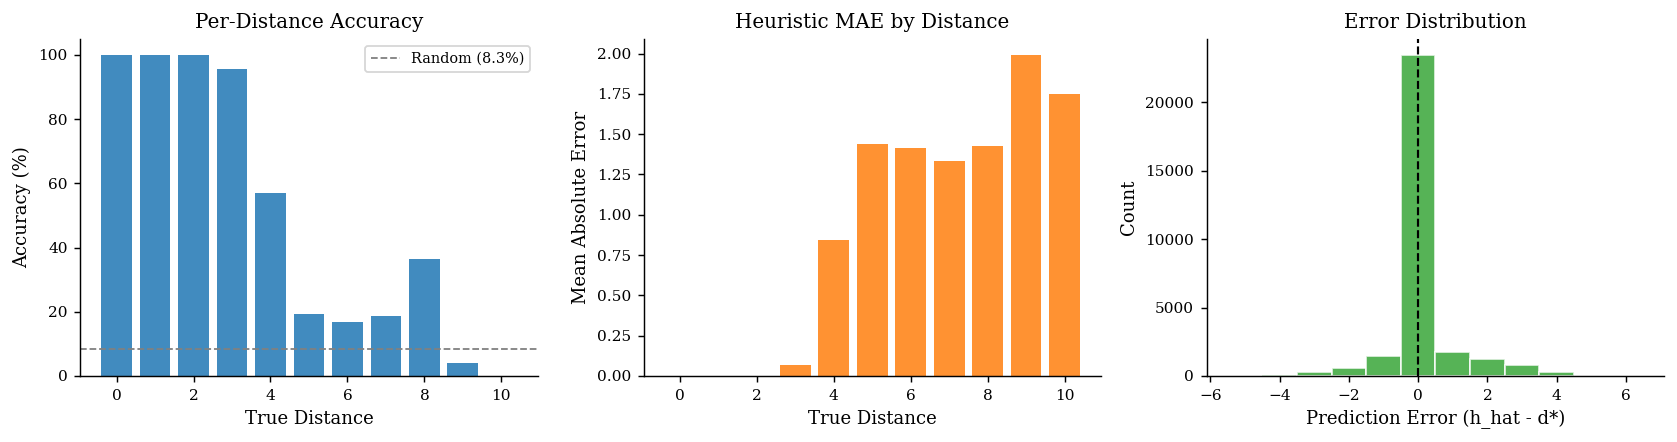

Saved heuristic_quality.pdf


In [17]:
distances_list = sorted(depth_acc.keys())

all_errors = [v for errs in depth_errors.values() for v in errs]
overestimate_pct = 100 * np.mean(np.array(all_errors) > 0)
print(f"Overall overestimate rate: {overestimate_pct:.1f}%  ({'NOT ' if overestimate_pct > 0 else ''}admissible)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# Per-distance accuracy
axes[0].bar(distances_list, [depth_acc[d]*100 for d in distances_list], color="#1f77b4", alpha=0.85)
axes[0].axhline(100/12, color="gray", linestyle="--", linewidth=1, label="Random (8.3%)")
axes[0].set_xlabel("True Distance")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Per-Distance Accuracy")
axes[0].legend(fontsize=8)

# Per-distance MAE
axes[1].bar(distances_list, [depth_mae[d] for d in distances_list], color="#ff7f0e", alpha=0.85)
axes[1].set_xlabel("True Distance")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("Heuristic MAE by Distance")

# Error distribution
error_vals = np.array(all_errors)
bins = np.arange(error_vals.min() - 0.5, error_vals.max() + 1.5)
axes[2].hist(error_vals, bins=bins, color="#2ca02c", alpha=0.8, edgecolor="white")
axes[2].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[2].set_xlabel("Prediction Error (h_hat - d*)")
axes[2].set_ylabel("Count")
axes[2].set_title("Error Distribution")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "heuristic_quality.pdf", bbox_inches="tight")
plt.show()
print("Saved heuristic_quality.pdf")


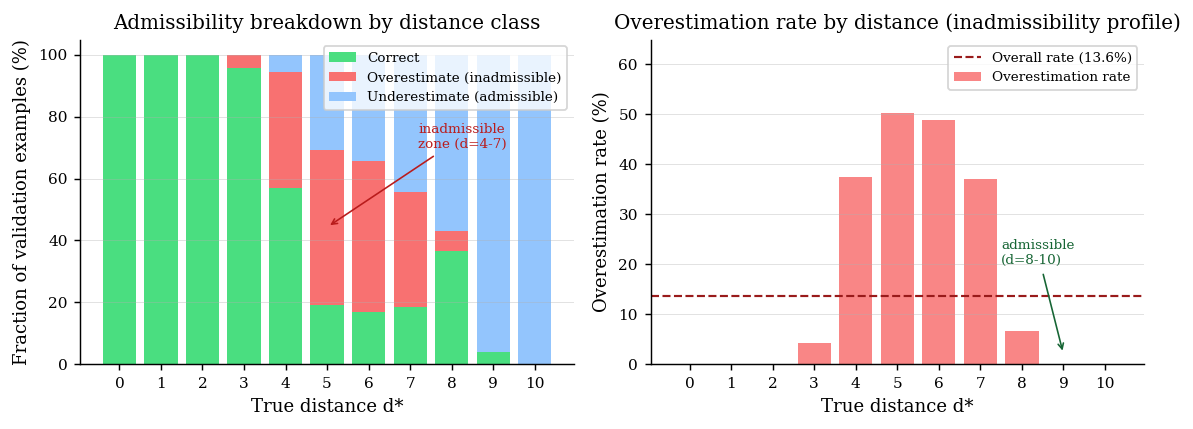

Saved overestimation.pdf


In [18]:
# Use depth_errors from best_model evaluation (cell 19) directly
dist_range = list(range(11))
n_over_list    = []
n_correct_list = []
n_under_list   = []
totals_list    = []

for d in dist_range:
    errs = np.array(depth_errors.get(d, []))
    n = len(errs)
    totals_list.append(n)
    if n == 0:
        n_over_list.append(0); n_correct_list.append(0); n_under_list.append(0)
    else:
        n_over_list.append(int((errs > 0).sum()))
        n_correct_list.append(int((errs == 0).sum()))
        n_under_list.append(int((errs < 0).sum()))

pct_over    = [100 * o / t if t else 0 for o, t in zip(n_over_list,    totals_list)]
pct_correct = [100 * c / t if t else 0 for c, t in zip(n_correct_list, totals_list)]
pct_under   = [100 * u / t if t else 0 for u, t in zip(n_under_list,   totals_list)]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

# Left: stacked bar (admissibility breakdown)
ax = axes[0]
x = np.array(dist_range)
ax.bar(x, pct_correct, color="#4ade80", label="Correct")
ax.bar(x, pct_over,    bottom=pct_correct, color="#f87171", label="Overestimate (inadmissible)")
ax.bar(x, pct_under,
       bottom=[c + o for c, o in zip(pct_correct, pct_over)],
       color="#93c5fd", label="Underestimate (admissible)")

ax.set_xlabel("True distance d*")
ax.set_ylabel("Fraction of validation examples (%)")
ax.set_xticks(dist_range)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=7.5)
ax.grid(axis="y", linewidth=0.4, alpha=0.5)
ax.set_title("Admissibility breakdown by distance class")

if len(pct_over) > 5 and pct_over[5] > 0:
    ax.annotate("inadmissible\nzone (d=4-7)",
                xy=(5, pct_over[5] / 2 + pct_correct[5]),
                xytext=(7.2, 70),
                fontsize=7.5, color="#b91c1c",
                arrowprops=dict(arrowstyle="->", color="#b91c1c", lw=0.9))

# Right: overestimation rate bar chart
ax2 = axes[1]
ax2.bar(x, pct_over, color="#f87171", alpha=0.85, label="Overestimation rate")
overall_rate = 100 * sum(n_over_list) / sum(totals_list) if sum(totals_list) > 0 else 0
ax2.axhline(overall_rate, color="#991b1b", linestyle="--", linewidth=1.2,
            label=f"Overall rate ({overall_rate:.1f}%)")
ax2.set_xlabel("True distance d*")
ax2.set_ylabel("Overestimation rate (%)")
ax2.set_xticks(dist_range)
ax2.set_ylim(0, 65)
ax2.legend(fontsize=7.5)
ax2.grid(axis="y", linewidth=0.4, alpha=0.5)
ax2.set_title("Overestimation rate by distance (inadmissibility profile)")

ax2.annotate("admissible\n(d=8-10)", xy=(9, 2), xytext=(7.5, 20),
             fontsize=7.5, color="#166534",
             arrowprops=dict(arrowstyle="->", color="#166534", lw=0.9))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "overestimation.pdf", bbox_inches="tight")
plt.show()
print("Saved overestimation.pdf")


In [19]:
def filter_normalize(direction, reference):
    "Scale each filter in direction to match the Frobenius norm of reference."
    out = []
    for d, w in zip(direction, reference):
        if w.dim() > 1:
            w_norms = w.view(w.shape[0], -1).norm(dim=1, keepdim=True)
            d_norms = d.view(d.shape[0], -1).norm(dim=1, keepdim=True) + 1e-10
            scale = (w_norms / d_norms).view(-1, *([1] * (w.dim() - 1)))
            out.append(d * scale)
        else:
            out.append(d * (w.norm() / (d.norm() + 1e-10)))
    return out


def compute_loss_landscape(model, loader, device, class_weights,
                           grid_size=21, alpha_range=1.0, seed=42):
    "Evaluate loss on a 2D perturbation grid around model weights."
    weights = [p.data.clone() for p in model.parameters()]
    cw = class_weights.to(device)

    torch.manual_seed(seed)
    dir1 = filter_normalize([torch.randn_like(w) for w in weights], weights)
    dir2 = filter_normalize([torch.randn_like(w) for w in weights], weights)

    alphas = np.linspace(-alpha_range, alpha_range, grid_size)
    betas  = np.linspace(-alpha_range, alpha_range, grid_size)
    loss_grid = np.zeros((grid_size, grid_size))

    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            for p, w, d1, d2 in zip(model.parameters(), weights, dir1, dir2):
                p.data.copy_(w + alpha * d1 + beta * d2)
            total_loss = total = 0
            with torch.no_grad():
                for states_b, targets_b in loader:
                    states_b, targets_b = states_b.to(device), targets_b.to(device)
                    loss = F.cross_entropy(model(states_b), targets_b, weight=cw, reduction="sum")
                    total_loss += loss.item()
                    total      += len(targets_b)
            loss_grid[i, j] = total_loss / total
        if (i + 1) % 5 == 0:
            print(f"  Row {i+1}/{grid_size} done")

    # Restore original weights
    for p, w in zip(model.parameters(), weights):
        p.data.copy_(w)

    return alphas, betas, loss_grid


_landscape_cache = RESULTS_DIR / "loss_landscape.npz"
if _landscape_cache.exists():
    print("[cached] loss_landscape.npz")
    _data = np.load(_landscape_cache)
    alphas, betas, loss_grid = _data["alphas"], _data["betas"], _data["loss_grid"]
else:
    print("Computing loss landscape (this takes ~5-10 min)...")
    alphas, betas, loss_grid = compute_loss_landscape(
        best_model, val_loader, device, class_weights,
        grid_size=21, alpha_range=1.0,
    )
    np.savez(_landscape_cache, alphas=alphas, betas=betas, loss_grid=loss_grid)
    print("Done. Saved loss_landscape.npz")


[cached] loss_landscape.npz


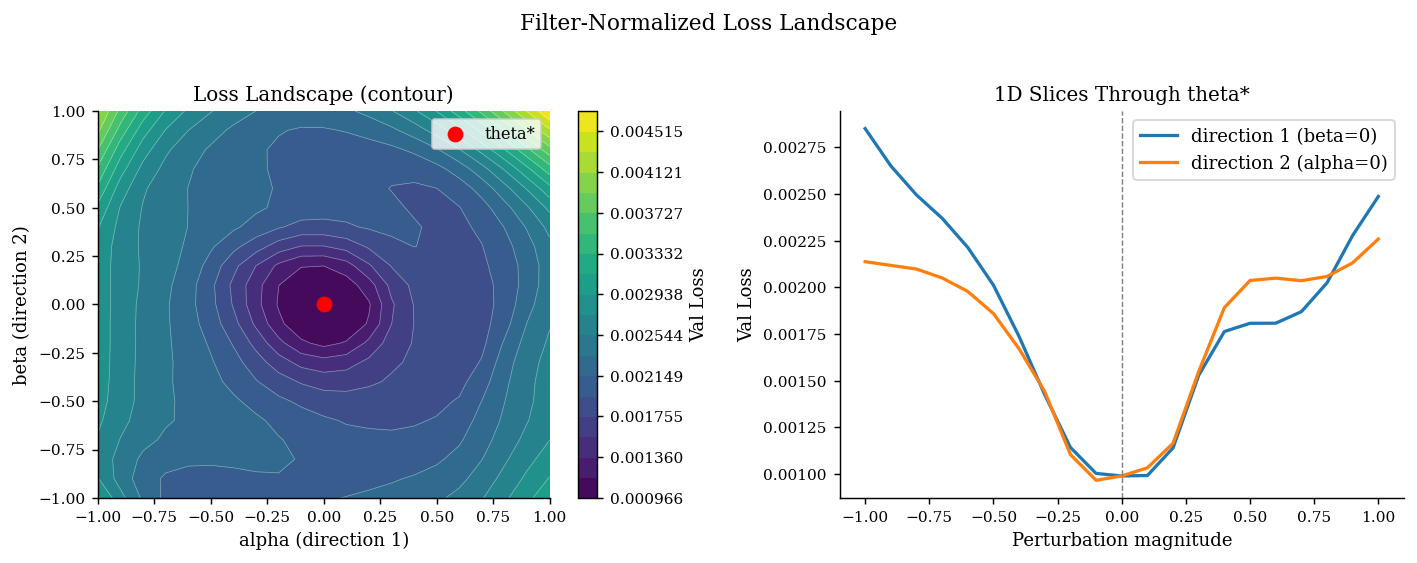

Saved loss_landscape.pdf


In [20]:
# Use alphas, betas, loss_grid from cell 22 (no file reload needed)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Contour plot
A, B = np.meshgrid(alphas, betas, indexing="ij")
center_loss = loss_grid[len(alphas)//2, len(betas)//2]
levels = np.linspace(loss_grid.min(), min(loss_grid.max(), center_loss * 5), 20)
cf = axes[0].contourf(A, B, loss_grid, levels=levels, cmap="viridis")
axes[0].contour(A, B, loss_grid, levels=levels, colors="white", linewidths=0.4, alpha=0.4)
axes[0].scatter([0], [0], color="red", s=60, zorder=5, label="theta*")
fig.colorbar(cf, ax=axes[0], label="Val Loss")
axes[0].set_xlabel("alpha (direction 1)")
axes[0].set_ylabel("beta (direction 2)")
axes[0].set_title("Loss Landscape (contour)")
axes[0].legend(fontsize=9)

# 1D slices through center
mid = len(alphas) // 2
axes[1].plot(alphas, loss_grid[:, mid], color="#1f77b4", label="direction 1 (beta=0)", linewidth=1.8)
axes[1].plot(betas,  loss_grid[mid, :], color="#ff7f0e", label="direction 2 (alpha=0)", linewidth=1.8)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Perturbation magnitude")
axes[1].set_ylabel("Val Loss")
axes[1].set_title("1D Slices Through theta*")
axes[1].legend()

fig.suptitle("Filter-Normalized Loss Landscape", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "loss_landscape.pdf", bbox_inches="tight")
plt.show()
print("Saved loss_landscape.pdf")


## A* Search with Learned Heuristic

Deploy the trained model as a search heuristic: f(s) = g(s) + h(s) where
h(s) = model-predicted distance. Compare against Dijkstra (h=0, i.e. BFS)
as a baseline.

Metrics: nodes expanded (search efficiency) and solution optimality
(solution length == BFS optimal distance).

Node limit: 10,000 per search.


In [21]:
MAX_NODES = 10_000
N_PER_DIST = 20   # test cases per distance


def _state_1hot_to_int8(state_1hot):
    "Convert (144,) float32 one-hot -> (24,) int8 color indices."
    return np.argmax(state_1hot.reshape(24, 6), axis=1).astype(np.int8)


def _encode_int8_to_1hot(state_int8):
    "Convert (24,) int8 -> (144,) float32 one-hot."
    out = np.zeros(144, dtype=np.float32)
    for i, c in enumerate(state_int8):
        out[i * 6 + int(c)] = 1.0
    return out


@torch.no_grad()
def _batch_h(states_list, model, device):
    "Predict distance for a list of (24,) int8 states. Returns list[int]."
    vecs = np.stack([_encode_int8_to_1hot(s) for s in states_list])
    t = torch.from_numpy(vecs).to(device)
    return model(t).argmax(dim=-1).cpu().numpy().tolist()


def astar_search(start_int8, model, device, max_nodes=MAX_NODES, use_heuristic=True):
    "A* (or Dijkstra if use_heuristic=False) from start_int8 to SOLVED_STATE."
    if np.array_equal(start_int8, SOLVED_STATE):
        return 0, 0

    h0 = _batch_h([start_int8], model, device)[0] if use_heuristic else 0
    counter = 0
    heap = [(h0, 0, counter, start_int8.tobytes())]
    best_g = {pack_state(start_int8): 0}
    nodes_expanded = 0

    while heap and nodes_expanded < max_nodes:
        _, g, _, state_bytes = heapq.heappop(heap)
        state = np.frombuffer(state_bytes, dtype=np.int8).copy()
        key = pack_state(state)

        if g > best_g.get(key, float("inf")):
            continue
        nodes_expanded += 1

        succs, keys, gs = [], [], []
        for m in range(NUM_MOVES):
            ns = Cube(state.copy()).apply_move(m).state
            ng = g + 1
            nk = pack_state(ns)
            if ng < best_g.get(nk, float("inf")):
                best_g[nk] = ng
                if np.array_equal(ns, SOLVED_STATE):
                    return ng, nodes_expanded
                succs.append(ns); keys.append(nk); gs.append(ng)

        if not succs:
            continue

        h_vals = _batch_h(succs, model, device) if use_heuristic else [0] * len(succs)
        for ns, nk, ng, h in zip(succs, keys, gs, h_vals):
            counter += 1
            heapq.heappush(heap, (ng + h, ng, counter, ns.tobytes()))

    return None, nodes_expanded


astar_out = RESULTS_DIR / "astar_results.json"

if astar_out.exists():
    print("[cached] astar_results.json")
    astar_data = json.loads(astar_out.read_text())
else:
    val_states = val_data["states"]
    val_dists  = val_data["optimal_distance"].astype(int)

    astar_data = {}
    for d in range(1, 11):
        idxs = np.where(val_dists == d)[0]
        if len(idxs) == 0:
            continue
        rng = np.random.default_rng(seed=d)
        sampled = rng.choice(idxs, size=min(N_PER_DIST, len(idxs)), replace=False)

        a_res, dijk_res = [], []
        for idx in sampled:
            s = _state_1hot_to_int8(val_states[idx])

            sl, ne = astar_search(s, best_model, device, use_heuristic=True)
            a_res.append({"sol_len": sl, "nodes": ne,
                          "optimal": bool(sl == d) if sl is not None else None,
                          "success": sl is not None})

            sl2, ne2 = astar_search(s, best_model, device, use_heuristic=False)
            dijk_res.append({"sol_len": sl2, "nodes": ne2,
                             "optimal": bool(sl2 == d) if sl2 is not None else None,
                             "success": sl2 is not None})

        a_succ = sum(r["success"] for r in a_res)
        d_succ = sum(r["success"] for r in dijk_res)
        a_med  = int(np.median([r["nodes"] for r in a_res]))
        print(f"  d={d:2d}: A* {a_succ}/{len(sampled)} success, median nodes={a_med:5d} | "
              f"Dijkstra {d_succ}/{len(sampled)} success")

        astar_data[str(d)] = {"d": d, "n": len(sampled),
                               "astar": a_res, "dijkstra": dijk_res}

    astar_out.write_text(json.dumps(astar_data, indent=2))
    print(f"Saved {astar_out}")

print(f"A* done. MAX_NODES={MAX_NODES:,}  N_PER_DIST={N_PER_DIST}")


[cached] astar_results.json
A* done. MAX_NODES=10,000  N_PER_DIST=20


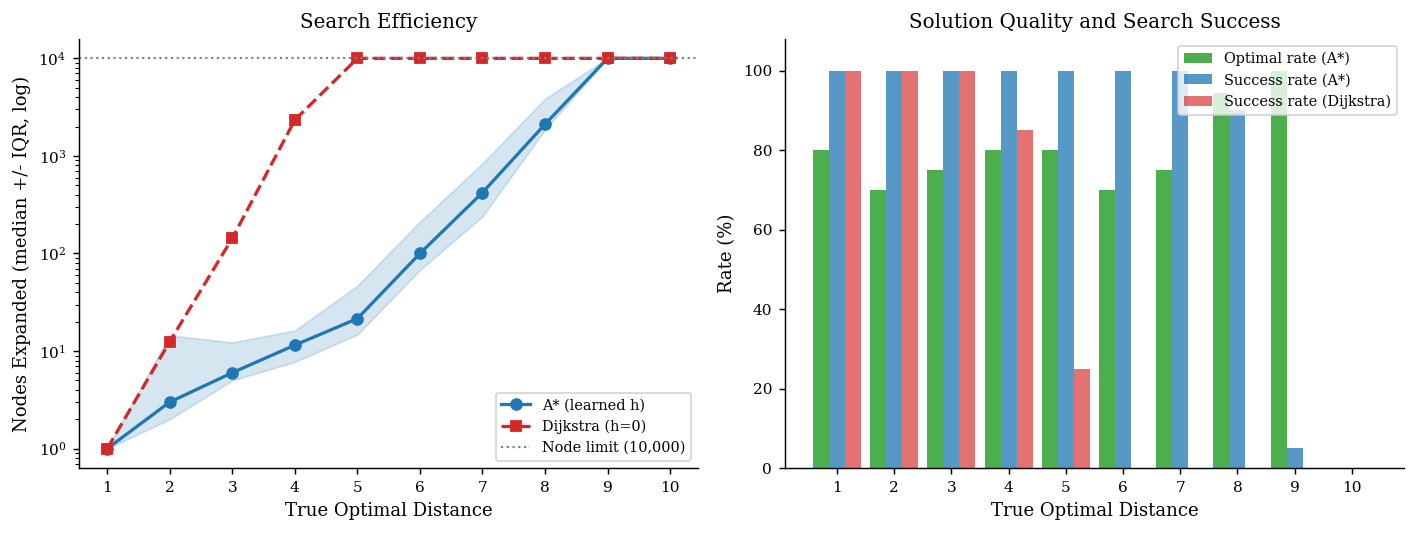

Saved astar_results.pdf


In [22]:
distances_astar = sorted(int(d) for d in astar_data.keys())

a_nodes_med, a_nodes_q1, a_nodes_q3 = [], [], []
d_nodes_med = []
a_success, d_success, a_optimal = [], [], []

for d in distances_astar:
    r = astar_data[str(d)]
    a_n = [x["nodes"] for x in r["astar"]]
    d_n = [x["nodes"] for x in r["dijkstra"]]

    a_nodes_med.append(float(np.median(a_n)))
    a_nodes_q1.append(float(np.percentile(a_n, 25)))
    a_nodes_q3.append(float(np.percentile(a_n, 75)))
    d_nodes_med.append(float(np.median(d_n)))

    a_success.append(100 * np.mean([x["success"] for x in r["astar"]]))
    d_success.append(100 * np.mean([x["success"] for x in r["dijkstra"]]))
    opt = [x["optimal"] for x in r["astar"] if x["success"]]
    a_optimal.append(100 * np.mean(opt) if opt else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.semilogy(distances_astar, a_nodes_med, "o-",  color="#1f77b4", linewidth=1.8, label="A* (learned h)")
ax.fill_between(distances_astar, a_nodes_q1, a_nodes_q3, color="#1f77b4", alpha=0.18)
ax.semilogy(distances_astar, d_nodes_med,   "s--", color="#d62728", linewidth=1.8, label="Dijkstra (h=0)")
ax.axhline(MAX_NODES, color="gray", linestyle=":", linewidth=1.2,
           label=f"Node limit ({MAX_NODES:,})")
ax.set_xlabel("True Optimal Distance")
ax.set_ylabel("Nodes Expanded (median +/- IQR, log)")
ax.set_title("Search Efficiency")
ax.set_xticks(distances_astar)
ax.legend(fontsize=8)

ax2 = axes[1]
w = 0.28
xs = np.array(distances_astar)
ax2.bar(xs - w, a_optimal,  width=w, color="#2ca02c", alpha=0.85, label="Optimal rate (A*)")
ax2.bar(xs,     a_success,  width=w, color="#1f77b4", alpha=0.75, label="Success rate (A*)")
ax2.bar(xs + w, d_success,  width=w, color="#d62728", alpha=0.65, label="Success rate (Dijkstra)")
ax2.set_xlabel("True Optimal Distance")
ax2.set_ylabel("Rate (%)")
ax2.set_title("Solution Quality and Search Success")
ax2.set_xticks(distances_astar)
ax2.set_ylim(0, 108)
ax2.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "astar_results.pdf", bbox_inches="tight")
plt.show()
print("Saved astar_results.pdf")


In [23]:
print(f"{'Experiment':<35} {'Final Val Acc':>14} {'Best Val Acc':>13}")
print("-" * 64)

all_results = {
    "AdamW (cosine)":    results_opt["adamw"],
    "Adam (cosine)":     results_opt["adam"],
    "SGD+mom (cosine)":  results_opt["sgd"],
    "AdamW (step)":      results_sched["step"],
    "AdamW (constant)":  results_sched["constant"],
    **{f"d_model={d}": h for d, h in results_dmodel.items() if d != 128},
    **{f"wd={wd:.0e}": h for wd, h in results_wd.items()},
}

for name, hist in all_results.items():
    final = hist[-1]["val_acc"] * 100
    best  = max(h["val_acc"] for h in hist) * 100
    print(f"{name:<35} {final:>13.1f}%  {best:>12.1f}%")


Experiment                           Final Val Acc  Best Val Acc
----------------------------------------------------------------
AdamW (cosine)                               79.8%          79.9%
Adam (cosine)                                79.7%          79.8%
SGD+mom (cosine)                             74.2%          74.4%
AdamW (step)                                 76.4%          76.9%
AdamW (constant)                             76.1%          77.9%
d_model=64                                   78.8%          79.1%
d_model=256                                  82.2%          82.3%
wd=0e+00                                     79.8%          80.1%
wd=1e-04                                     78.8%          78.8%
wd=1e-03                                     78.5%          78.8%
wd=1e-02                                     78.7%          78.7%
